# CRNN (PaddleOCR) on UIT Handwritten Vietnamese

Notebook này tập trung **thử nghiệm nhanh trên Kaggle H100** cho bài toán recognition chữ viết tay tiếng Việt:
- Dataset: **UIT_HWDB_line_converted** (line-level, đã cắt sẵn)
- Model: **CRNN** (CTC) fine-tune từ tiếng Anh
- Đánh giá bằng **CER** và **NED**

> Notebook chỉ cung cấp code để chạy trên Kaggle, không tự động chạy train.

### Bước 0.1 - Cài Môi Trường Nền (Kaggle)
Mục tiêu:
- Đồng bộ môi trường cho PaddleOCR trên Kaggle H100.
- Cài `paddlepaddle-gpu`, `paddlex`, `huggingface_hub` và các thư viện tiện ích.

Ghi chú:
- Cell này chỉ cần chạy 1 lần mỗi phiên runtime mới.
- Nếu Kaggle báo cần restart runtime sau khi cài package, hãy restart rồi chạy lại từ đầu notebook.

In [1]:
# ------------------------=
# 0.1) Install base dependencies
# ------------------------=
import sys
import subprocess

# Tránh conflict từ stack torch preinstalled (notebook này chỉ dùng Paddle)
subprocess.run([
    sys.executable, '-m', 'pip', 'uninstall', '-y',
    'torch', 'torchvision', 'torchaudio', 'triton',
    'fastai', 'fastcore', 'fastdownload', 'nbdev'
], check=False)

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'pip', 'setuptools', 'wheel'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'paddlepaddle-gpu==3.0.0', '-i', 'https://www.paddlepaddle.org.cn/packages/stable/cu126/'])

import paddle
print('Paddle version:', paddle.__version__)
print('CUDA available:', paddle.device.is_compiled_with_cuda())
print('GPU count:', paddle.device.cuda.device_count())
for i in range(paddle.device.cuda.device_count()):
    print(f'GPU {i}:', paddle.device.cuda.get_device_name(i))

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: triton 3.6.0
Uninstalling triton-3.6.0:
  Successfully uninstalled triton-3.6.0
Found existing installation: fastai 2.8.7
Uninstalling fastai-2.8.7:
  Successfully uninstalled fastai-2.8.7
Found existing installation: fastcore 1.12.16
Uninstalling fastcore-1.12.16:
  Successfully uninstalled fastcore-1.12.16
Found existing installation: fastdownload 0.0.7
Uninstalling fastdownload-0.0.7:
  Successfully uninstalled fastdownload-0.0.7
Found existing installation: nbdev 3.0.12
Uninstalling nbdev-3.0.12:
  Successfully uninstalled nbdev-3.0.12
   ━━━━━━━━

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle version: 3.0.0
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


### Bước 0.2 - Clone PaddleOCR và Cài Requirements
Mục tiêu:
- Tạo thư mục PaddleOCR trong `/kaggle/working`.
- Cài các dependency chuẩn từ `requirements.txt` của PaddleOCR.

Output mong đợi:
- In ra đường dẫn repo và xác nhận đã sẵn sàng train/infer.

In [2]:
# ------------------------=
# 0.2) Clone PaddleOCR repo
# ------------------------=
import os
from pathlib import Path

PADDLEOCR_DIR_BOOTSTRAP = Path('/kaggle/working/PaddleOCR')
if not PADDLEOCR_DIR_BOOTSTRAP.is_dir():
    !git clone --depth 1 https://github.com/PaddlePaddle/PaddleOCR.git {PADDLEOCR_DIR_BOOTSTRAP}

!pip install -q -r {PADDLEOCR_DIR_BOOTSTRAP}/requirements.txt
print('PaddleOCR ready:', PADDLEOCR_DIR_BOOTSTRAP)

Cloning into '/kaggle/working/PaddleOCR'...
remote: Enumerating objects: 2552, done.
remote: Counting objects: 100% (2552/2552), done.
remote: Compressing objects: 100% (1896/1896), done.
remote: Total 2552 (delta 709), reused 1923 (delta 592), pack-reused 0 (from 0)
Receiving objects: 100% (2552/2552), 95.55 MiB | 41.07 MiB/s, done.
Resolving deltas: 100% (709/709), done.
PaddleOCR ready: /kaggle/working/PaddleOCR


### Bước 0.3 - Đăng Nhập Hugging Face Token (Tuỳ Chọn)
Mục tiêu:
- Đăng nhập Hugging Face để tải dataset/model private nếu cần.

Cách dùng trên Kaggle:
- Vào `Add-ons -> Secrets`, tạo secret tên `HF_TOKEN`.
- Chạy cell bên dưới để login tự động.

In [3]:
# # ------------------------=
# # 0.3) HuggingFace login via Kaggle Secrets
# # ------------------------=
# import subprocess
# import sys

# # Bao dam huggingface_hub da co
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'huggingface_hub'])

# from kaggle_secrets import UserSecretsClient
# from huggingface_hub import login

# user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("HF_TOKEN")

# if secret_value_0 and str(secret_value_0).strip():
#     login(str(secret_value_0).strip())
#     print('HF login success via kaggle_secrets.HF_TOKEN')
# else:
#     print('HF_TOKEN secret is empty or missing.')

### Bước 1 - Environment Setup
Cell này import thư viện, khai báo đường dẫn dữ liệu/output.

**Thay đổi so với bản Manga109:**
- `DATASET_INPUT` trỏ thẳng tới thư mục dataset Kaggle read-only (`/kaggle/input/...`).
- Dataset UIT đã cắt sẵn line-level → không cần crop/preprocess.
- Label file sử dụng trực tiếp `labels.txt` có sẵn trong dataset.
- Dictionary chuyển sang tiếng Việt (`dict_vietnamese.txt`).
- `use_space_char = True` vì tiếng Việt có dấu cách giữa các từ.

In [4]:
# ------------------------=
# 1) Environment setup
# ------------------------=
import os
import re
import cv2
import yaml
import json
import math
import shutil
import random
import unicodedata
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)

# -Đường dẫn dataset UIT trên Kaggle (read-only) ----
# Kaggle mount dataset tại /kaggle/input/<dataset-slug>/
# Hãy thay 'uit-handwritten-dataset' bằng slug thực tế của dataset trên Kaggle.
DATASET_SLUG = 'datasets/khangphantrnvn/uit-handwriten-dataset'  
DATASET_INPUT = Path(f'/kaggle/input/{DATASET_SLUG}/UIT_HWDB_line_converted')

TRAIN_INPUT_DIR = DATASET_INPUT / 'train_data'   # chứa images/ và labels.txt
TEST_INPUT_DIR  = DATASET_INPUT / 'test_data'    # chứa images/ và labels.txt

PADDLEOCR_DIR = Path('/kaggle/working/PaddleOCR')
OUTPUT_ROOT   = Path('/kaggle/working/exp_crnn_uit_hwdb')

# -Working directories (writable) ----
WORK_DATA    = OUTPUT_ROOT / 'data'
TRAIN_LABEL  = WORK_DATA / 'rec_gt_train.txt'   # PaddleOCR-format label cho train
VAL_LABEL    = WORK_DATA / 'rec_gt_val.txt'      # PaddleOCR-format label cho test/val
DICT_PATH    = WORK_DATA / 'dict_vietnamese.txt'  # Từ điển ký tự tiếng Việt

CONFIG_PATH  = OUTPUT_ROOT / 'crnn_uit_hwdb.yml'
TRAIN_LOG    = OUTPUT_ROOT / 'train.log'
EVAL_JSON    = OUTPUT_ROOT / 'eval_cer_ned.json'

for p in [OUTPUT_ROOT, WORK_DATA]:
    p.mkdir(parents=True, exist_ok=True)

print('DATASET_INPUT =', DATASET_INPUT)
print('TRAIN_INPUT   =', TRAIN_INPUT_DIR)
print('TEST_INPUT    =', TEST_INPUT_DIR)
print('PADDLEOCR_DIR =', PADDLEOCR_DIR)
print('OUTPUT_ROOT   =', OUTPUT_ROOT)

DATASET_INPUT = /kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted
TRAIN_INPUT   = /kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/train_data
TEST_INPUT    = /kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/test_data
PADDLEOCR_DIR = /kaggle/working/PaddleOCR
OUTPUT_ROOT   = /kaggle/working/exp_crnn_uit_hwdb


### Bước 2 - Kiểm Tra Dataset & Chuyển Đổi Label
Mục tiêu:
- Kiểm tra dataset UIT đã được mount đúng trên Kaggle.
- Đọc `labels.txt` có sẵn trong `train_data/` và `test_data/`.
- Chuyển đổi sang format PaddleOCR: `<đường_dẫn_ảnh_tuyệt_đối>\t<text>`.

**Vì sao cần chuyển đổi?**
- File `labels.txt` gốc dùng relative path `images/1_1.jpg`, nhưng dataset nằm ở `/kaggle/input/` (read-only).
- PaddleOCR `SimpleDataSet` nối `data_dir + rel_path` để tìm ảnh → ta cần đảm bảo path khớp chính xác.
- Không cần copy ảnh (tiết kiệm disk), chỉ cần label file trỏ đúng path.

**Không cần pre-process cắt ảnh** vì dataset UIT đã ở dạng line-level (mỗi ảnh = 1 dòng chữ).

In [5]:
# ------------------------=
# 2) Validate dataset & convert labels to PaddleOCR format
# ------------------------=
from pathlib import Path


def convert_uit_labels(input_dir: Path, out_label_path: Path, split_name: str) -> int:
    """
    Đọc labels.txt từ thư mục UIT (train_data hoặc test_data)
    và ghi ra file label chuẩn PaddleOCR.

    Format gốc:  images/1_1.jpg\tKHÁI QUÁT VỀ BIỂN ĐẢO VIỆT NAM
    Format output: images/1_1.jpg\tKHÁI QUÁT VỀ BIỂN ĐẢO VIỆT NAM
    (giữ nguyên relative path, PaddleOCR sẽ nối data_dir phía trước)
    """
    src_label = input_dir / 'labels.txt'
    if not src_label.exists():
        raise FileNotFoundError(f'Không tìm thấy {src_label}')

    num_valid = 0
    num_skipped = 0

    with open(src_label, 'r', encoding='utf-8') as fin, \
         open(out_label_path, 'w', encoding='utf-8') as fout:
        for line_num, line in enumerate(fin, 1):
            line = line.strip()
            if not line or '\t' not in line:
                num_skipped += 1
                continue

            rel_path, text = line.split('\t', 1)
            text = text.strip()

            # Kiểm tra ảnh tồn tại
            img_path = input_dir / rel_path
            if not img_path.exists():
                num_skipped += 1
                continue

            if not text:
                num_skipped += 1
                continue

            # Ghi ra label chuẩn PaddleOCR (giữ nguyên relative path)
            fout.write(f'{rel_path}\t{text}\n')
            num_valid += 1

    print(f'[{split_name}] Valid: {num_valid} | Skipped: {num_skipped}')
    return num_valid


# Kiểm tra mount ---
assert DATASET_INPUT.exists(), f'Dataset chưa được mount! Kiểm tra: {DATASET_INPUT}'
assert TRAIN_INPUT_DIR.exists(), f'Thiếu train_data: {TRAIN_INPUT_DIR}'
assert TEST_INPUT_DIR.exists(), f'Thiếu test_data: {TEST_INPUT_DIR}'

print(' Dataset mount OK')
print(f'  Train images dir: {TRAIN_INPUT_DIR / "images"}')
print(f'  Test  images dir: {TEST_INPUT_DIR / "images"}')

# Liệt kê 1 vài file ảnh để xác nhận
train_imgs = sorted((TRAIN_INPUT_DIR / 'images').glob('*.jpg'))[:5]
print(f'\nSample train images ({len(train_imgs)} shown):')
for p in train_imgs:
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

# Chuyển đổi labels ---
n_train = convert_uit_labels(TRAIN_INPUT_DIR, TRAIN_LABEL, 'Train')
n_val   = convert_uit_labels(TEST_INPUT_DIR,  VAL_LABEL,   'Test/Val')

# In vài dòng mẫu
print('\nSample TRAIN labels ---')
with open(TRAIN_LABEL, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 4:
            break

print('\nSample VAL labels ---')
with open(VAL_LABEL, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.rstrip())
        if i >= 4:
            break

 Dataset mount OK
  Train images dir: /kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/train_data/images
  Test  images dir: /kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/test_data/images

Sample train images (5 shown):
  100_1.jpg  (63.4 KB)
  100_10.jpg  (66.9 KB)
  100_11.jpg  (65.5 KB)
  100_12.jpg  (67.9 KB)
  100_13.jpg  (69.9 KB)
[Train] Valid: 7028 | Skipped: 0
[Test/Val] Valid: 201 | Skipped: 0

Sample TRAIN labels ---
images/1_1.jpg	KHÁI QUÁT VỀ BIỂN ĐẢO VIỆT NAM
images/1_2.jpg	Nước ta giáp với biển Đông ở hai phía Đông và Nam. Vùng biển Việt Nam là một phần biển
images/1_3.jpg	Đông.
images/1_4.jpg	Bờ biển dài 3.260 km, từ Quảng Ninh đến Kiên Giang. Như vậy cứ 100 km2 thì có 1 km bờ biển
images/1_5.jpg	(trung bình của thế giới là 600 km2 đất liền / 1 km bờ biển)

Sample VAL labels ---
images/250_1.jpg	Thứ trưởng Bộ Tài nguyên & môi trường Đặng Hùng Võ tâm đắc với
images/250_2.jpg	cơ chế " khuyến khích 

### Bước 3 - Tạo Từ Điển Tiếng Việt (Dictionary)
Mục tiêu:
- Quét toàn bộ ký tự xuất hiện trong **cả train và test labels** để tạo `dict_vietnamese.txt`.
- File dictionary chứa mỗi dòng 1 ký tự, là đầu vào bắt buộc cho CTC Head của PaddleOCR.

**Vì sao tạo từ cả train + test?**
- Đảm bảo model có thể decode được mọi ký tự xuất hiện trong tập test.
- Nếu chỉ dùng train, test có thể chứa ký tự ngoài dictionary → model không decode được → CER tăng giả.
- Dictionary không ảnh hưởng tới việc model "nhìn thấy" test data vì nó chỉ là bảng map index ↔ ký tự.

In [6]:
# ------------------------=
# 3) Build Vietnamese character dictionary from train + test labels
# ------------------------=

def build_dict_from_labels(*label_paths: Path) -> List[str]:
    """
    Quét tất cả ký tự từ các file label, trả về danh sách ký tự đã sắp xếp.
    Bỏ qua ký tự tab và newline.
    """
    char_set = set()
    for lp in label_paths:
        with open(lp, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or '\t' not in line:
                    continue
                _, text = line.split('\t', 1)
                for ch in text:
                    if ch not in ('\t', '\n', '\r'):
                        char_set.add(ch)
    return sorted(char_set)


chars = build_dict_from_labels(TRAIN_LABEL, VAL_LABEL)

with open(DICT_PATH, 'w', encoding='utf-8') as f:
    for ch in chars:
        f.write(ch + '\n')

print(f'Dictionary saved to: {DICT_PATH}')
print(f'Total unique characters: {len(chars)}')
print(f"Has space: {' ' in chars or '  ' in chars}")

# In một số ký tự mẫu
print(f'\nFirst 50 chars: {"".join(chars[:50])}')
print(f'Last  30 chars: {"".join(chars[-30:])}')

# Thống kê nhóm ký tự
n_alpha = sum(1 for c in chars if c.isalpha())
n_digit = sum(1 for c in chars if c.isdigit())
n_space = sum(1 for c in chars if c == ' ')
n_other = len(chars) - n_alpha - n_digit - n_space
print(f'\nAlpha: {n_alpha} | Digit: {n_digit} | Space: {n_space} | Other: {n_other}')

Dictionary saved to: /kaggle/working/exp_crnn_uit_hwdb/data/dict_vietnamese.txt
Total unique characters: 161
Has space: True

First 50 chars:  !"%&()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXY
Last  30 chars: ỆệỉịọỏỐốỒồổỗộớờỞởỡợụỦủứừửữựỳỷỹ

Alpha: 136 | Digit: 10 | Space: 1 | Other: 14


### Bước 4 - Trực Quan Hóa Phân Bố Độ Dài Text
Mục tiêu:
- Phân tích phân bố độ dài (số ký tự) của text trong train và test labels.
- Dựa vào kết quả để chọn giá trị `max_text_length` hợp lý cho config YAML.

**Vì sao quan trọng?**
- `max_text_length` quá nhỏ → cắt bỏ text dài → model không học được câu dài, CER tăng.
- `max_text_length` quá lớn → lãng phí bộ nhớ CTC, training chậm hơn.
- Mục tiêu: chọn giá trị bao phủ ~99% dữ liệu (percentile 99).

--- Text Length Statistics (Train + Test) ---
  Count : 7229
  Min   : 2
  Max   : 158
  Mean  : 67.7
  Median: 71
  Std   : 18.5

  P 90.0 : 86 chars
  P 95.0 : 90 chars
  P 99.0 : 99 chars
  P 99.5 : 102 chars
  P100.0 : 158 chars


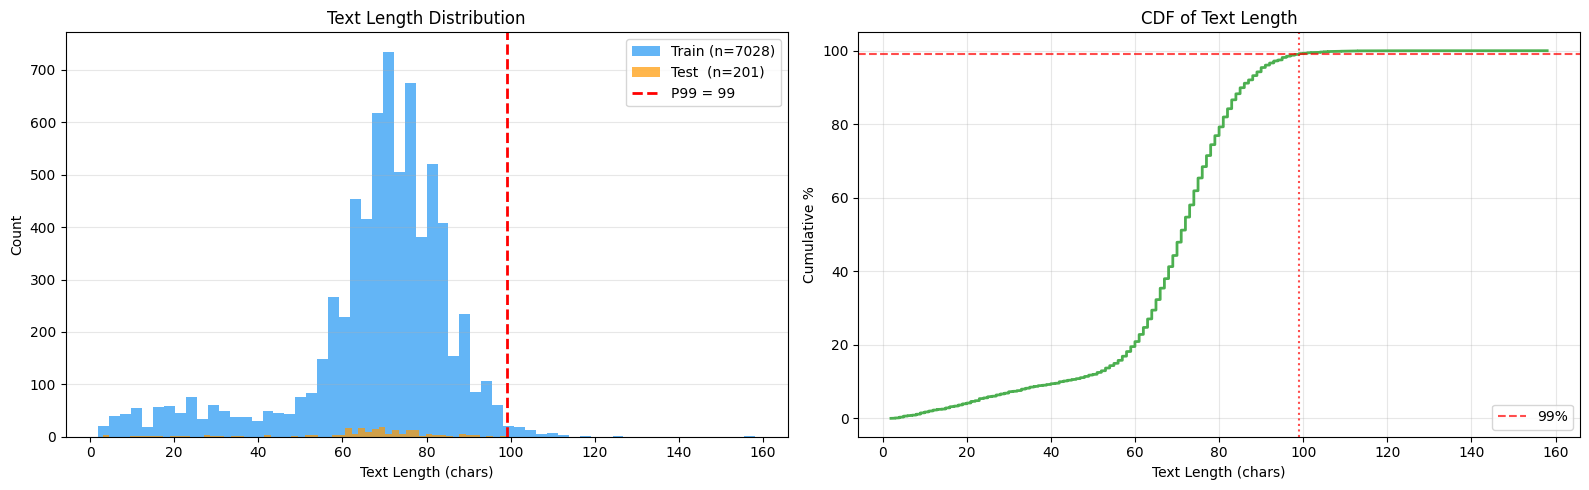


 GỢI Ý: max_text_length = 100
    (Bao phủ 99% dữ liệu, rounded up to nearest 10)
    Nếu muốn bao phủ 100%: max_text_length = 158


In [7]:
# ------------------------=
# 4) Visualize text length distribution → choose max_text_length
# ------------------------=
import matplotlib.pyplot as plt
import numpy as np


def read_text_lengths(label_path: Path) -> List[int]:
    lengths = []
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '\t' not in line:
                continue
            _, text = line.split('\t', 1)
            lengths.append(len(text))
    return lengths


train_lengths = read_text_lengths(TRAIN_LABEL)
val_lengths   = read_text_lengths(VAL_LABEL)
all_lengths   = train_lengths + val_lengths

# Thống kê ---
arr = np.array(all_lengths)
print('--- Text Length Statistics (Train + Test) ---')
print(f'  Count : {len(arr)}')
print(f'  Min   : {arr.min()}')
print(f'  Max   : {arr.max()}')
print(f'  Mean  : {arr.mean():.1f}')
print(f'  Median: {np.median(arr):.0f}')
print(f'  Std   : {arr.std():.1f}')
print()
for pct in [90, 95, 99, 99.5, 100]:
    val = np.percentile(arr, pct)
    print(f'  P{pct:5.1f} : {val:.0f} chars')

# Histogram ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Full distribution
axes[0].hist(train_lengths, bins=60, alpha=0.7, label=f'Train (n={len(train_lengths)})', color='#2196F3')
axes[0].hist(val_lengths,   bins=60, alpha=0.7, label=f'Test  (n={len(val_lengths)})',   color='#FF9800')
axes[0].axvline(np.percentile(arr, 99), color='red', linestyle='--', linewidth=2, label=f'P99 = {np.percentile(arr, 99):.0f}')
axes[0].set_xlabel('Text Length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Text Length Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# CDF
sorted_lens = np.sort(arr)
cdf = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens) * 100
axes[1].plot(sorted_lens, cdf, color='#4CAF50', linewidth=2)
axes[1].axhline(99, color='red', linestyle='--', alpha=0.7, label='99%')
axes[1].axvline(np.percentile(arr, 99), color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Text Length (chars)')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('CDF of Text Length')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Gợi ý max_text_length ---
suggested = int(np.ceil(np.percentile(arr, 99) / 10) * 10)  # Làm tròn lên bội 10
print(f'\n GỢI Ý: max_text_length = {suggested}')
print(f'    (Bao phủ 99% dữ liệu, rounded up to nearest 10)')
print(f'    Nếu muốn bao phủ 100%: max_text_length = {arr.max()}')

### Bước 4.5 - Chia Tập Huấn Luyện (Stratified Split)
Mục tiêu:
- Tập dữ liệu huấn luyện hiện tại (train_data) sẽ được chia thành 2 phần: tập huấn luyện (90%) và tập đánh giá (10%).
- Đảm bảo phân phối độ dài văn bản (text length) tương đồng giữa hai tập dữ liệu (Stratified Split).
- Các file mới sẽ được ghi tiếp thành `rec_gt_train_split.txt` và `rec_gt_val_split.txt`.

In [8]:
# -------------------------
# 4.5) Phân chia tập dữ liệu huấn luyện (Stratified by Text Length)
# -------------------------
import pandas as pd
from sklearn.model_selection import train_test_split

lines = []
lengths = []

with open(TRAIN_LABEL, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line or '\t' not in line:
            continue
        text = line.split('\t', 1)[1]
        lines.append(line)
        lengths.append(len(text))

df = pd.DataFrame({'line': lines, 'length': lengths})
# Gom chiều dài theo bins (10 phần vị)
df['len_bin'] = pd.qcut(df['length'], q=10, labels=False, duplicates='drop')

# Tách dataset với size 10% val, bảo toàn len_bin
train_df, val_df = train_test_split(df, test_size=0.1, random_state=SEED, stratify=df['len_bin'])

TRAIN_SPLIT_LABEL = WORK_DATA / 'rec_gt_train_split.txt'
VAL_SPLIT_LABEL   = WORK_DATA / 'rec_gt_val_split.txt'

with open(TRAIN_SPLIT_LABEL, 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_df['line'].tolist()))

with open(VAL_SPLIT_LABEL, 'w', encoding='utf-8') as f:
    f.write('\n'.join(val_df['line'].tolist()))

print(f"Số lượng mẫu Huấn luyện (Train): {len(train_df)}")
print(f"Số lượng mẫu Đánh giá (Val): {len(val_df)}")


Số lượng mẫu Huấn luyện (Train): 6325
Số lượng mẫu Đánh giá (Val): 703


### Bước 5 - Tải Pretrained CRNN (Chinese)
Cell này khai báo checkpoint pretrained khởi tạo theo bản tiếng Trung (`ch_ppocr_mobile_v2.0_rec_train`).

**Vì sao dùng pretrained Chinese cho tiếng Việt?**
- Backbone (MobileNetV3) đã học tốt việc trích xuất feature từ ảnh text → transfer learning.
- Chỉ cần fine-tune Head layer (CTC) cho bộ ký tự tiếng Việt.
- PaddleOCR tự động bỏ qua các trọng số không khớp shape (do khác dictionary size).

In [9]:
# ------------------------=
# 5) Download pretrained CRNN (optional)
# ------------------------=
PRETRAINED_DIR = OUTPUT_ROOT / 'pretrained'
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)

# Dùng pretrained Chinese CRNN làm khởi tạo
PRETRAINED_URL = 'https://paddleocr.bj.bcebos.com/dygraph_v2.0/en/rec_r34_vd_none_bilstm_ctc_v2.0_train.tar'
PRETRAINED_TAR = PRETRAINED_DIR / 'rec_r34_vd_none_bilstm_ctc_v2.0_train.tar'
PRETRAINED_ROOT = PRETRAINED_DIR / 'rec_r34_vd_none_bilstm_ctc_v2.0_train'
PRETRAINED_PATH = PRETRAINED_ROOT / 'best_accuracy'

print('Pretrained URL :', PRETRAINED_URL)
print('Pretrained path:', PRETRAINED_PATH)

# Uncomment on Kaggle when running:
!wget -q --show-progress -O {PRETRAINED_TAR} {PRETRAINED_URL}
!tar -xf {PRETRAINED_TAR} -C {PRETRAINED_DIR}

Pretrained URL : https://paddleocr.bj.bcebos.com/dygraph_v2.0/en/rec_r34_vd_none_bilstm_ctc_v2.0_train.tar
Pretrained path: /kaggle/working/exp_crnn_uit_hwdb/pretrained/rec_r34_vd_none_bilstm_ctc_v2.0_train/best_accuracy
/kaggle/working/exp 100%[===================>] 447.87M  15.7MB/s    in 51s     


### Bước 6 - Sinh YAML Config Huấn Luyện
Cell này tạo file config PaddleOCR cho CRNN (CTC), dùng dữ liệu UIT đã chuẩn bị.

**Thay đổi quan trọng so với bản Manga109:**
- `data_dir` trong Train trỏ về `TRAIN_INPUT_DIR` (chứa images/), trong Eval trỏ về `TEST_INPUT_DIR`.
- `character_dict_path` → `dict_vietnamese.txt`.
- `use_space_char: True` vì tiếng Việt có khoảng trắng giữa các từ.
- `max_text_length` → lấy từ kết quả trực quan hóa ở Bước 4.

In [10]:
# ------------------------=
# 6) Build PaddleOCR train config (CRNN ResNet34)
# ------------------------=
import yaml
from pathlib import Path

def count_lines(path: Path) -> int:
    with open(path, 'r', encoding='utf-8') as f:
        return sum(1 for _ in f)

# -Điều chỉnh max_text_length dựa trên kết quả Bước 4 ----
MAX_TEXT_LENGTH = 100  # <-- CHỈNH THEO KẾT QUẢ BƯỚC 4

N_GPU = 2
# ↓ GIẢM BATCH SIZE: ResNet34 nặng hơn MobileNet rất nhiều. 
# Nếu máy báo lỗi Out of Memory (OOM), hãy giảm tiếp xuống 64 hoặc 32.
BATCH_PER_CARD = 128  

n_train = count_lines(TRAIN_SPLIT_LABEL)
steps_per_epoch = max(1, n_train // (BATCH_PER_CARD * N_GPU))
eval_step = max(500, steps_per_epoch * 2)

cfg = {
    'Global': {
        'use_gpu': True,
        'distributed': True,
        'epoch_num': 80,
        'log_smooth_window': 20,
        'print_batch_step': 20,
        'save_model_dir': str(OUTPUT_ROOT / 'output'),
        'save_epoch_step': 2,
        'eval_batch_step': [0, eval_step],
        'cal_metric_during_train': True,
        'pretrained_model': str(PRETRAINED_PATH),
        'character_dict_path': str(DICT_PATH),
        'max_text_length': MAX_TEXT_LENGTH,
        'infer_mode': False,
        'use_space_char': True,   
        'save_res_path': str(OUTPUT_ROOT / 'predicts.txt'),
        'seed': SEED,
        'freeze_backbone': False,
    },
    'Optimizer': {
        'name': 'Adam',
        'beta1': 0.9,
        'beta2': 0.999,
        # ↓ Điều chỉnh LR giảm một chút (từ 8e-4 xuống 5e-4) vì ResNet sâu hơn
        'lr': {'name': 'Cosine', 'learning_rate': 5e-4, 'warmup_epoch': 2},
        'regularizer': {'name': 'L2', 'factor': 1e-4},
    },
    'Architecture': {
        'model_type': 'rec',
        'algorithm': 'CRNN',
        'Transform': None,
        # ↓ ĐỔI BACKBONE SANG RESNET 34
        'Backbone': {
            'name': 'ResNet', 
            'layers': 34
        },
        # ↓ TĂNG HIDDEN SIZE (Từ 96 lên 256) để khớp với feature map của ResNet
        'Neck': {
            'name': 'SequenceEncoder', 
            'encoder_type': 'rnn', 
            'hidden_size': 256
        },
        'Head': {'name': 'CTCHead', 'fc_decay': 0},
    },
    'Loss': {'name': 'CTCLoss'},
    'PostProcess': {'name': 'CTCLabelDecode'},
    'Metric': {'name': 'RecMetric', 'main_indicator': 'acc'},
    'Train': {
        'dataset': {
            'name': 'SimpleDataSet',
            'data_dir': str(TRAIN_INPUT_DIR),
            'label_file_list': [str(TRAIN_SPLIT_LABEL)],
            'transforms': [
                {'DecodeImage': {'img_mode': 'BGR', 'channel_first': False}},
                {'HandwritingAug': {'aug_prob': 0.8}},
                {'CTCLabelEncode': None},
                {'RecResizeImg': {'image_shape': [3, 32, 640]}},
                {'KeepKeys': {'keep_keys': ['image', 'label', 'length']}},
            ],
        },
        'loader': {
            'shuffle': True,
            'batch_size_per_card': BATCH_PER_CARD,
            'drop_last': True,
            'num_workers': 4,
            'use_shared_memory': True,
        },
    },
    'Eval': {
        'dataset': {
            'name': 'SimpleDataSet',
            'data_dir': str(TRAIN_INPUT_DIR),
            'label_file_list': [str(VAL_SPLIT_LABEL)],
            'transforms': [
                {'DecodeImage': {'img_mode': 'BGR', 'channel_first': False}},
                {'CTCLabelEncode': None},
                # Cập nhật ảnh test lên 640 để đồng nhất với lúc train
                {'RecResizeImg': {'image_shape': [3, 32, 640]}},
                {'KeepKeys': {'keep_keys': ['image', 'label', 'length']}},
            ],
        },
        'loader': {
            'shuffle': False,
            'drop_last': False,
            'batch_size_per_card': BATCH_PER_CARD,
            'num_workers': 4,
            'use_shared_memory': True,
        },
    },
}

with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False, allow_unicode=True)

print('Config saved to:', CONFIG_PATH)
print('Train samples:', n_train)
print('Val samples  :', count_lines(VAL_SPLIT_LABEL))
print(f'max_text_length: {MAX_TEXT_LENGTH}')
print(f'use_space_char : True')
print(f'batch_size     : {BATCH_PER_CARD}')

Config saved to: /kaggle/working/exp_crnn_uit_hwdb/crnn_uit_hwdb.yml
Train samples: 6325
Val samples  : 703
max_text_length: 100
use_space_char : True
batch_size     : 128


In [11]:
with open('/kaggle/working/PaddleOCR/tools/train.py', 'r', encoding='utf-8') as f:
    print("Code đếm tham số đã được bơm vào chưa?:", "COUNT PARAMETERS" in f.read())

Code đếm tham số đã được bơm vào chưa?: False


In [12]:
# Bước 6.5 - Patch Custom Augmentation và Freeze Stage 1
# Cell này patch ppocr/data/imaug/handwriting_aug.py, đăng ký import và thêm freeze_backbone + early stopping vào PaddleOCR.
# ------------------------=
# 6.5) Patch custom augmentation + stage1 freeze logic
import os

PADDLEOCR_DIR = str(PADDLEOCR_DIR)
AUG_DIR = os.path.join(PADDLEOCR_DIR, 'ppocr', 'data', 'imaug')
AUG_FILE = os.path.join(AUG_DIR, 'handwriting_aug.py')
INIT_FILE = os.path.join(AUG_DIR, '__init__.py')
program_py = os.path.join(PADDLEOCR_DIR, 'tools', 'program.py')
train_py = os.path.join(PADDLEOCR_DIR, 'tools', 'train.py')

os.makedirs(AUG_DIR, exist_ok=True)

aug_code = '''import cv2
import numpy as np
import random

class HandwritingAug:
    def __init__(self, aug_prob=0.5, **kwargs):
        self.aug_prob = float(aug_prob)

    def __call__(self, data):
        if random.random() > self.aug_prob:
            return data
        img = data.get('image')
        if img is None or img.size == 0:
            return data
        try:
            img = self._brightness(img)
            img = self._contrast(img)
            img = self._blur(img)
            img = self._shear(img)
            img = self._random_erase(img)
        except Exception:
            pass
        data['image'] = img
        return data

    def _brightness(self, img):
        if random.random() < 0.5:
            f = random.uniform(0.7, 1.3)
            img = np.clip(img.astype(np.float32) * f, 0, 255).astype(np.uint8)
        return img

    def _contrast(self, img):
        if random.random() < 0.5:
            mean = img.mean()
            f = random.uniform(0.7, 1.3)
            img = np.clip((img.astype(np.float32) - mean) * f + mean, 0, 255).astype(np.uint8)
        return img

    def _blur(self, img):
        if random.random() < 0.3:
            k = random.choice([3, 5])
            img = cv2.GaussianBlur(img, (k, k), 0)
        return img

    def _shear(self, img):
        if random.random() < 0.4:
            h, w = img.shape[:2]
            s = random.uniform(-0.08, 0.08)
            M = np.float32([[1, s, 0], [0, 1, 0]])
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
        return img

    def _random_erase(self, img):
        if random.random() < 0.3:
            h, w = img.shape[:2]
            for _ in range(random.randint(1, 2)):
                pw = random.randint(2, max(3, w // 15))
                ph = random.randint(2, max(3, h // 4))
                x = random.randint(0, max(0, w - pw))
                y = random.randint(0, max(0, h - ph))
                img[y:y+ph, x:x+pw] = 255
        return img
'''

with open(AUG_FILE, 'w', encoding='utf-8') as f:
    f.write(aug_code)
print(' Wrote HandwritingAug to', AUG_FILE)

init_line = 'from ppocr.data.imaug.handwriting_aug import HandwritingAug'
if os.path.exists(INIT_FILE):
    with open(INIT_FILE, 'r', encoding='utf-8') as f:
        init_content = f.read()
else:
    init_content = ''

if init_line not in init_content:
    with open(INIT_FILE, 'a', encoding='utf-8') as f:
        if init_content and not init_content.endswith('\n'):
            f.write('\n')
        f.write('# [PATCH] custom augmentation\n' + init_line + '\n')
    print(' Patched __init__.py for HandwritingAug import')
else:
    print(' HandwritingAug import already present')

with open(program_py, 'r', encoding='utf-8') as f:
    content = f.read()

EARLY_STOP_PATIENCE = 10
if 'early_stop_counter' not in content:
    content = content.replace('best_model_dict = {', 'early_stop_counter = 0\n    best_model_dict = {', 1)
    old_save = "save_model(\n"\
               "                        model,\n"\
               "                        optimizer,\n"\
               "                        best_model_dict['best_model_dir'],\n"\
               "                        logger,\n"\
               "                        config,\n"\
               "                        is_best=True)"
    new_save = old_save + '\n                    early_stop_counter = 0  # Reset early stop counter'
    content = content.replace(old_save, new_save, 1)
    old_else = '                else:\n                    logger.info'
    idx = content.find(old_else, content.find('is_best=True'))
    if idx > 0:
        insert_after_else = (
            '                else:\n'
            '                    early_stop_counter += 1\n'
            f'                    logger.info("Early stop counter: {{early_stop_counter}}/{EARLY_STOP_PATIENCE}")\n'
            f'                    if early_stop_counter >= {EARLY_STOP_PATIENCE}:\n'
            '                        logger.info("Early stopping triggered!")\n'
            '                        break\n'
            '                    logger.info'
        )
        content = content[:idx] + insert_after_else + content[idx + len(old_else):]
    with open(program_py, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f' Patched early stopping (patience={EARLY_STOP_PATIENCE})')
else:
    print(' Early stopping already patched')

with open(train_py, 'r', encoding='utf-8') as f:
    train_content = f.read()

# Kiểm tra xem file đã được patch hay chưa
if 'freeze_backbone' not in train_content:
    # LƯU Ý 1: Phải dùng ngoặc kép (") vì file gốc của PaddleOCR viết bằng ngoặc kép
    anchor = 'model = build_model(config["Architecture"])'
    
    inject = '''model = build_model(config["Architecture"])
    
    # ---------------------------------------------------------
    # [PATCH] FREEZE BACKBONE LOGIC
    # ---------------------------------------------------------
    if config["Global"].get("freeze_backbone", False):
        logger.info(" ĐÓNG BĂNG BACKBONE VÀ NECK (STAGE 1)...")
        for name, param in model.named_parameters():
            if 'backbone' in name.lower():
                param.stop_gradient = True
                if hasattr(param, 'trainable'):
                    param.trainable = False
        logger.info(" Done freezing.")
    else:
        logger.info(" MỞ BĂNG TOÀN BỘ MÔ HÌNH (STAGE 2/FULL FINE-TUNING)...")
    
    # ---------------------------------------------------------
    # [PATCH] COUNT PARAMETERS
    # ---------------------------------------------------------
    try:
        # LƯU Ý 2: Dùng getattr an toàn hơn gọi trực tiếp p.stop_gradient
        trainable_params = sum(int(p.numel()) for p in model.parameters() if not getattr(p, 'stop_gradient', False))
        total_params = sum(int(p.numel()) for p in model.parameters())
        
        # Tránh lỗi chia cho 0
        percent = (trainable_params / total_params * 100) if total_params > 0 else 0
        
        msg = f" Trainable Parameters: {trainable_params:,} / {total_params:,} ({percent:.2f}%)"
        
        # LƯU Ý 3: Ép buộc in thẳng ra màn hình Kaggle bằng flush=True
        print("\\n" + "="*55, flush=True)
        print(msg, flush=True)
        print("="*55 + "\\n", flush=True)
        
        # Vẫn ghi vào file log của hệ thống
        if 'logger' in locals() and hasattr(logger, 'info'):
            logger.info(msg)
            
    except Exception as e:
        print(f"\\n [LỖI COUNT PARAMETERS]: {e}\\n", flush=True)

    '''
    
    # Thực hiện thay thế
    train_content = train_content.replace(anchor, inject, 1)
    
    with open(train_py, 'w', encoding='utf-8') as f:
        f.write(train_content)
        
    # Kiểm tra chéo xem code có thực sự được bơm vào file chưa
    if " Trainable Parameters" in train_content:
        print(' Patched freeze_backbone and param counter into train.py successfully!')
    else:
        print('❌ LỖI: Không tìm thấy dòng anchor để thay thế. File train.py chưa được thay đổi.')
        
else:
    print(' Freeze backbone already patched in train.py')


 Wrote HandwritingAug to /kaggle/working/PaddleOCR/ppocr/data/imaug/handwriting_aug.py
 Patched __init__.py for HandwritingAug import
 Patched early stopping (patience=10)
 Patched freeze_backbone and param counter into train.py successfully!


In [13]:
import re, os, json, datetime, csv

def parse_paddle_log(log_file_path: str, stage_name: str, out_dir: str):
    if not os.path.exists(log_file_path):
        print(f'  Log file not found: {log_file_path}')
        return

    with open(log_file_path, 'r', encoding='utf-8', errors='ignore') as fh:
        lines = fh.readlines()

    # ---== REGEX LINH HOẠT (QUAN TRỌNG) ---==
    epoch_pat  = re.compile(r'epoch:\s*\[(\d+)/(\d+)\]')
    step_pat   = re.compile(r'global_step:\s*(\d+)')
    loss_pat   = re.compile(r'loss:\s*([\d.eE+-]+)')
    lr_pat     = re.compile(r'lr:\s*([\d.eE+-]+)')

    eval_pat   = re.compile(r'cur metric.*?acc:\s*([\d.]+).*?norm_edit_dis:\s*([\d.]+)')
    best_pat   = re.compile(r'best metric.*?acc:\s*([\d.]+)')
    early_pat  = re.compile(r'Early stop(?:ping)?')

    train_steps = []
    eval_steps  = []
    best_records = []
    early_stopped = False

    current_epoch = -1
    total_epoch = -1

    for line in lines:
        # ---== Extract epoch ---==
        m = epoch_pat.search(line)
        if m:
            current_epoch = int(m.group(1))
            total_epoch   = int(m.group(2))

        # ---== Extract train step (KHÔNG phụ thuộc format) ---==
        if "loss:" in line and "epoch:" in line:
            step_match = step_pat.search(line)
            loss_match = loss_pat.search(line)
            lr_match   = lr_pat.search(line)

            if loss_match:
                train_steps.append({
                    'epoch': current_epoch,
                    'total_epoch': total_epoch,
                    'global_step': int(step_match.group(1)) if step_match else -1,
                    'lr': float(lr_match.group(1)) if lr_match else None,
                    'loss': float(loss_match.group(1))
                })

        # ---== Eval ---==
        m = eval_pat.search(line)
        if m:
            eval_steps.append({
                'epoch': current_epoch,
                'acc': float(m.group(1)),
                'norm_edit_dis': float(m.group(2))
            })

        # ---== Best ---==
        m = best_pat.search(line)
        if m:
            best_records.append({
                'epoch': current_epoch,
                'acc': float(m.group(1))
            })

        # ---== Early stop ---==
        if early_pat.search(line):
            early_stopped = True

    # ---== SUMMARY ---==
    summary_log = {
        'stage': stage_name,
        'log_file': log_file_path,
        'total_train_steps': len(train_steps),
        'total_eval_checkpoints': len(eval_steps),
        'early_stopped': early_stopped,
        'final_train_loss': train_steps[-1]['loss'] if train_steps else None,
        'final_global_step': train_steps[-1]['global_step'] if train_steps else None,
        'best_acc': max((e['acc'] for e in eval_steps), default=None),
        'best_norm_edit_dis': max((e['norm_edit_dis'] for e in eval_steps), default=None),
        'best_acc_epoch': best_records[-1]['epoch'] if best_records else None,
    }

    # ---== SAVE JSON ---==
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    os.makedirs(out_dir, exist_ok=True)

    json_out = os.path.join(out_dir, f'{stage_name}_log_{ts}.json')
    with open(json_out, 'w', encoding='utf-8') as fh:
        json.dump({
            'summary': summary_log,
            'train_steps': train_steps,
            'eval_steps': eval_steps,
            'best_records': best_records
        }, fh, ensure_ascii=False, indent=2)

    # ---== SAVE CSV ---==
    csv_out = os.path.join(out_dir, f'{stage_name}_train_steps_{ts}.csv')
    if train_steps:
        with open(csv_out, 'w', newline='', encoding='utf-8') as fh:
            writer = csv.DictWriter(fh, fieldnames=train_steps[0].keys())
            writer.writeheader()
            writer.writerows(train_steps)

    # ---== PRINT ---==
    print(f'\n{"─"*55}')
    print(f'  {stage_name.upper()} LOG SUMMARY')
    print(f'{"─"*55}')
    for k, v in summary_log.items():
        print(f'  {k:<30}: {v}')
    print(f'{"─"*55}')
    print(f'  JSON  → {json_out}')
    print(f'  CSV   → {csv_out}')

    return summary_log


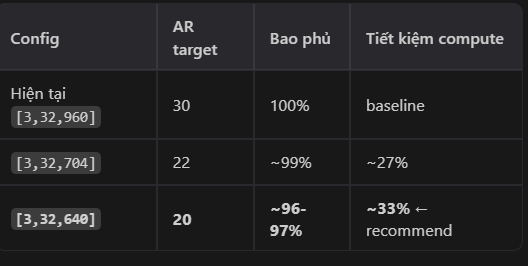

Target width   : ████████████████████████████████ 960px (AR=30)
Median image   : ████████████████░░░░░░░░░░░░░░░░ ~432px + 528px padding (55% lãng phí)


### Bước 6.5 - Patch Early Stopping và Freeze Backbone/Neck
Cell này patch `tools/program.py` và `tools/train.py` để dùng `freeze_backbone=True` tại stage 1 và dừng sớm khi không cải thiện.

In [14]:
# ------------------------=
# 7) Train command (Multi-GPU Shell Version)
# ------------------------=

import os
import shlex
from IPython import get_ipython

# -------------------------
# Khởi tạo thư mục
# -------------------------
stage1_dir = OUTPUT_ROOT / 'stage1'
stage2_dir = OUTPUT_ROOT / 'stage2'
stage1_dir.mkdir(parents=True, exist_ok=True)
stage2_dir.mkdir(parents=True, exist_ok=True)

stage1_best = stage1_dir / 'best_accuracy'

# Chuyển hướng làm việc vào thư mục PaddleOCR
os.chdir(PADDLEOCR_DIR)

# ------------------------=
# STAGE 1
# ------------------------=
print("\n--- STAGE 1: WARMUP HEAD (Freeze Backbone & Multi-GPU) ---")
print("  LR: 0.001 | No warmup | Max: 30 epochs")

# >>> ĐÃ THAY ĐỔI DÒNG DƯỚI ĐÂY <<<
train_cmd_stage1 = f"""python -m paddle.distributed.launch --gpus '0,1' tools/train.py \
    -c {shlex.quote(str(CONFIG_PATH))} \
    -o Global.pretrained_model={shlex.quote(str(PRETRAINED_PATH))} \
       Global.save_model_dir={shlex.quote(str(stage1_dir))} \
       Global.freeze_backbone=True \
       Global.epoch_num=30 \
       Global.save_epoch_step=5 \
       Optimizer.lr.learning_rate=0.0005 \
       Optimizer.lr.warmup_epoch=2 \
       Eval.loader.batch_size_per_card=128""".replace("\n", " ")

print("Dang chay Stage 1...")
LOG_DIR = f'{OUTPUT_ROOT}/logs'; os.makedirs(LOG_DIR, exist_ok=True)
get_ipython().system(train_cmd_stage1 + f' | tee {LOG_DIR}/stage1_train.log')
print("\n Done Stage 1!")
parse_paddle_log(f'{LOG_DIR}/stage1_train.log', 'stage1', LOG_DIR)

# ------------------------=
# STAGE 2
# ------------------------=
print("\n--- STAGE 2: FULL FINE-TUNING (Multi-GPU) ---")
print("  LR: 0.00005 | Warmup: 3 epochs | Max: 50 epochs")

# >>> ĐÃ THAY ĐỔI DÒNG DƯỚI ĐÂY <<<
train_cmd_stage2 = f"""python -m paddle.distributed.launch --gpus '0,1' tools/train.py \
    -c {shlex.quote(str(CONFIG_PATH))} \
    -o Global.pretrained_model={shlex.quote(str(stage1_best))} \
       Global.save_model_dir={shlex.quote(str(stage2_dir))} \
       Global.freeze_backbone=False \
       Global.epoch_num=50 \
       Global.save_epoch_step=10 \
       Optimizer.lr.learning_rate=0.00005 \
       Optimizer.lr.warmup_epoch=3 \
       Eval.loader.batch_size_per_card=64 \
       Train.loader.batch_size_per_card=32""".replace("\n", " ")

print("Dang chay Stage 2...")
LOG_DIR = f'{OUTPUT_ROOT}/logs'; os.makedirs(LOG_DIR, exist_ok=True)
get_ipython().system(train_cmd_stage2 + f' | tee {LOG_DIR}/stage2_train.log')
print("\n Done Stage 2!")
parse_paddle_log(f'{LOG_DIR}/stage2_train.log', 'stage2', LOG_DIR)



--- STAGE 1: WARMUP HEAD (Freeze Backbone & Multi-GPU) ---
  LR: 0.001 | No warmup | Max: 30 epochs
Dang chay Stage 1...
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
LAUNCH INFO 2026-04-21 09:35:35,713 -----------  Configuration  ----------------------
LAUNCH INFO 2026-04-21 09:35:35,713 auto_cluster_config: 0
LAUNCH INFO 2026-04-21 09:35:35,713 auto_parallel_config: None
LAUNCH INFO 2026-04-21 09:35:35,713 auto_tuner_json: None
LAUNCH INFO 2026-04-21 09:35:35,713 devices: 0,1
LAUNCH INFO 2026-04-21 09:35:35,713 elastic_level: -1
LAUNCH INFO 2026-04-21 09:35:35,713 elastic_timeout: 30
LAUNCH INFO 2026-04-21 09:35:35,713 enable_gpu_log: True
LAUNCH INFO 2026-04-21 09:35:35,713 gloo_port: 6767
LAUNCH INFO 2026-04-

{'stage': 'stage2',
 'log_file': '/kaggle/working/exp_crnn_uit_hwdb/logs/stage2_train.log',
 'total_train_steps': 290,
 'total_eval_checkpoints': 9,
 'early_stopped': False,
 'final_train_loss': 85.664223,
 'final_global_step': 4900,
 'best_acc': 0.0,
 'best_norm_edit_dis': 0.6332083890815942,
 'best_acc_epoch': 50}

### Bước 8 - Inference Trên Test Set
Cell này chuẩn bị danh sách ảnh test và gọi `predict_rec.py` để sinh dự đoán phục vụ tính metric.

--- INFERENCE với best model ---
  Model : /kaggle/working/exp_crnn_uit_hwdb/stage2/best_accuracy
  Images: /kaggle/input/datasets/khangphantrnvn/uit-handwriten-dataset/UIT_HWDB_line_converted/test_data/images
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/04/21 11:30:15] ppocr INFO: Architecture : 
[2026/04/21 11:30:15] ppocr INFO:     Backbone : 
[2026/04/21 11:30:15] ppocr INFO:         layers : 34
[2026/04/21 11:30:15] ppocr INFO:         name : ResNet
[2026/04/21 11:30:15] ppocr INFO:     Head : 
[2026/04/21 11:30:15] ppocr INFO:         fc_decay : 0
[2026/04/21 11:30:15] ppocr INFO:         name : CTCHead
[2026/04/21 11:30:15] ppocr INFO:     Neck : 
[2026/04/21

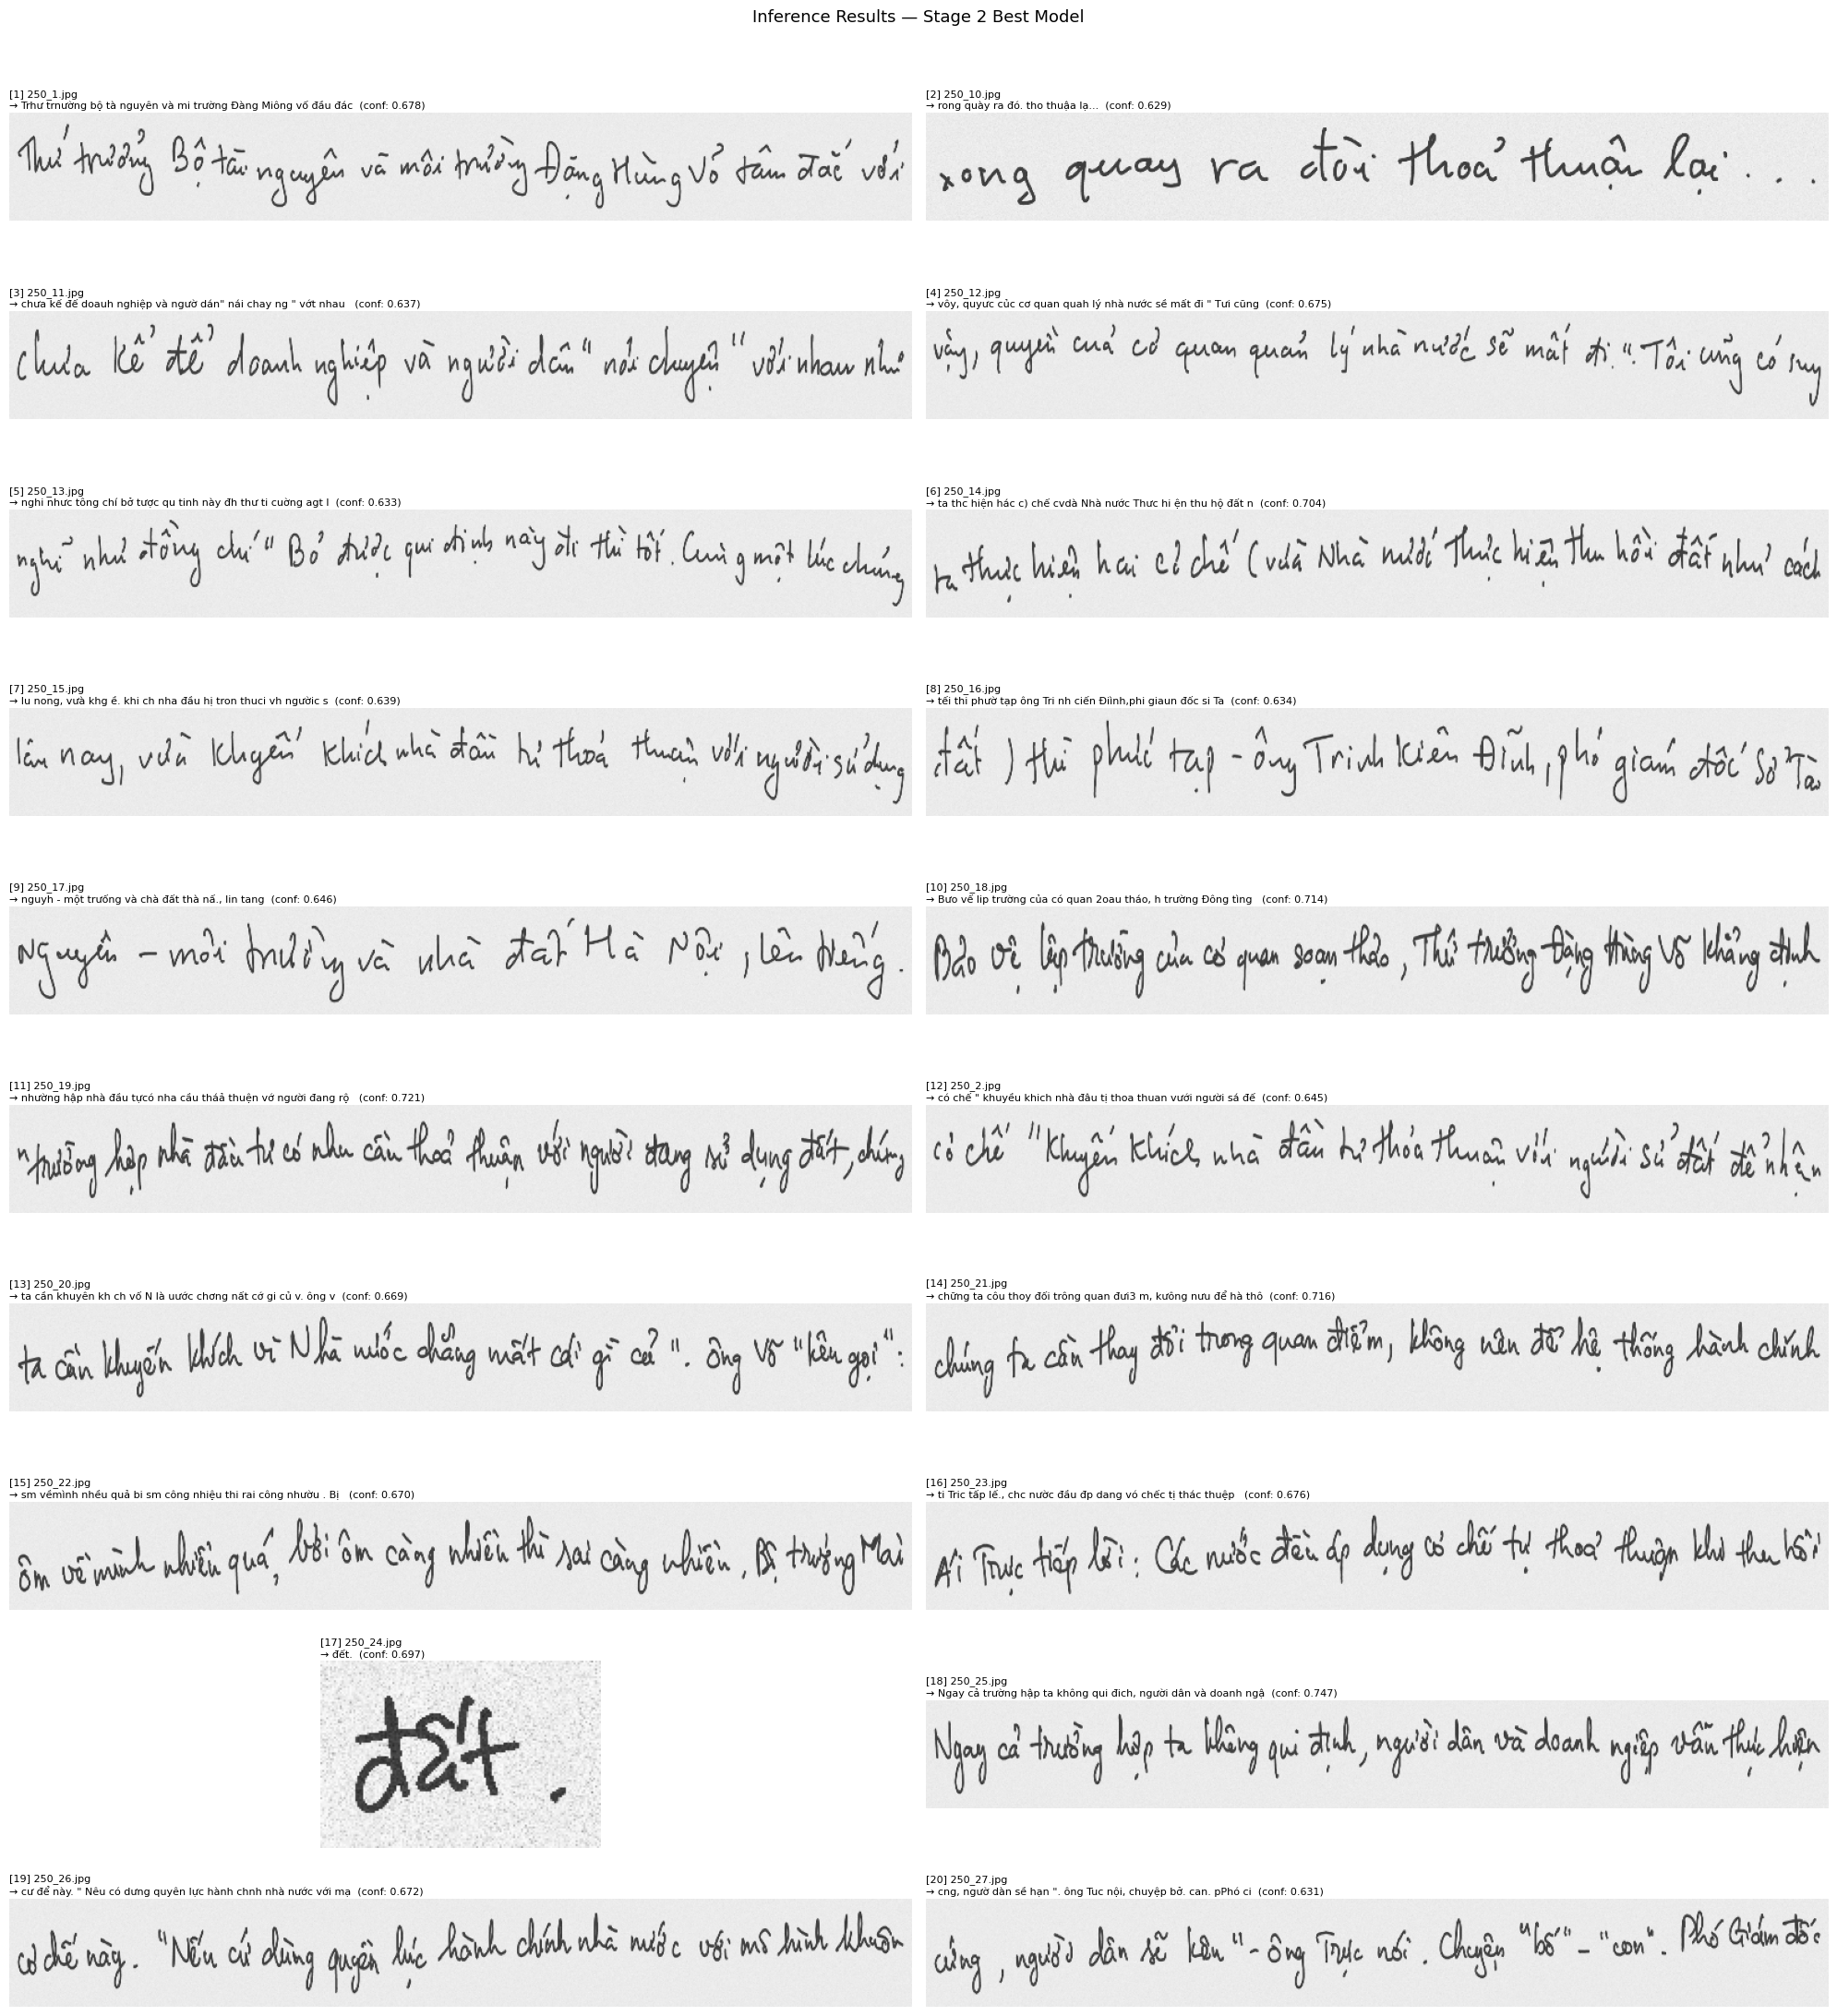

 Visualization saved: /kaggle/working/exp_crnn_uit_hwdb/visualizations/inference_preview.png
 Inference log: /kaggle/working/exp_crnn_uit_hwdb/logs/inference_log_20260421_113028.json


In [15]:
import matplotlib.pyplot as plt
os.chdir(PADDLEOCR_DIR)

# ── Paths ────────────────────────────────────────────────────
BEST_MODEL    = f'{OUTPUT_ROOT}/stage2/best_accuracy'
INFER_IMG_DIR = f'{DATASET_INPUT}/test_data/images'     
SAVE_RES      = f'{OUTPUT_ROOT}/inference_results.txt'
LOG_DIR       = f'{OUTPUT_ROOT}/logs'
VIZ_DIR       = f'{OUTPUT_ROOT}/visualizations'
CONFIG_PATH = str(CONFIG_PATH)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# ── 10-A  Chạy inference ─────────────────────────────────────
print('--- INFERENCE với best model ---')
print(f'  Model : {BEST_MODEL}')
print(f'  Images: {INFER_IMG_DIR}')

infer_cmd = f"""
python tools/infer_rec.py \\
    -c {shlex.quote(CONFIG_PATH)} \\
    -o Global.pretrained_model={BEST_MODEL} \\
       Global.infer_img={INFER_IMG_DIR} \\
       Global.save_res_path={SAVE_RES}
"""
get_ipython().system(infer_cmd)

# ── 10-B  Parse kết quả inference ────────────────────────────
preds = {}          # {img_name: {'text': ..., 'confidence': ...}}
raw_lines = []
if os.path.exists(SAVE_RES):
    with open(SAVE_RES, 'r', encoding='utf-8') as fh:
        raw_lines = fh.readlines()
    for line in raw_lines:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            img_name = os.path.basename(parts[0])
            preds[img_name] = {
                'text':       parts[1],
                'confidence': float(parts[2]) if len(parts) > 2 else None
            }
    print(f'\n Parsed {len(preds)} inference results.')
else:
    print('  Chưa có file kết quả inference. Kiểm tra lại đường dẫn model / image.')

# ── 10-C  Hiển thị 20 kết quả đầu + trực quan hóa ───────────
SHOW_N = 20
img_files = sorted([f for f in os.listdir(INFER_IMG_DIR)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))])[:SHOW_N]

def load_img_rgb(path, max_h=96):
    """Load ảnh BGR→RGB, resize về chiều cao cố định."""
    img = cv2.imread(path)
    if img is None:
        return np.ones((max_h, 300, 3), dtype=np.uint8) * 220
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    new_w = int(w * max_h / h) if h > 0 else 300
    return cv2.resize(img, (max_w := min(new_w, 800), max_h))

cols = 2
rows = (len(img_files) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 2.2))
axes = np.array(axes).flatten()

for ax in axes:
    ax.axis('off')

for idx, img_name in enumerate(img_files):
    img_path = os.path.join(INFER_IMG_DIR, img_name)
    pred_info = preds.get(img_name, {'text': '[MISSING]', 'confidence': None})
    pred_text = pred_info['text']
    conf_str  = f"  (conf: {pred_info['confidence']:.3f})" if pred_info['confidence'] else ''

    img_rgb = load_img_rgb(img_path)
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(
        f"[{idx+1}] {img_name}\n→ {pred_text[:60]}{conf_str}",
        fontsize=8, loc='left', pad=3
    )
    axes[idx].axis('off')

plt.suptitle('Inference Results — Stage 2 Best Model', fontsize=13, y=1.01)
plt.tight_layout()
viz_path = f'{VIZ_DIR}/inference_preview.png'
plt.savefig(viz_path, dpi=120, bbox_inches='tight')
plt.show()
print(f' Visualization saved: {viz_path}')

# ── 10-D  Lưu Inference Log (JSON) ───────────────────────────
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
infer_log = {
    'timestamp':     timestamp,
    'model':         BEST_MODEL,
    'image_dir':     INFER_IMG_DIR,
    'total_samples': len(preds),
    'results': [
        {'image': k, 'prediction': v['text'], 'confidence': v['confidence']}
        for k, v in preds.items()
    ]
}
log_path = f'{LOG_DIR}/inference_log_{timestamp}.json'
with open(log_path, 'w', encoding='utf-8') as fh:
    json.dump(infer_log, fh, ensure_ascii=False, indent=2)
print(f' Inference log: {log_path}')

### Bước 9 - Tính CER và NED
Cell này parse output inference, chuẩn hóa text, sau đó tính `CER`, `NED` và `Exact Match` để tham khảo.

Ground truth loaded: 201 samples
Predictions loaded : 201 samples

════════════════════════════════════════════════════════════
  EVALUATION METRICS
════════════════════════════════════════════════════════════
  Samples          : 201
  Exact Match Acc  : 0/201  = 0.00%
  Macro CER        : 37.47%
  Micro CER        : 37.60%
  Macro WER        : 86.89%
  Micro WER        : 87.06%
  Macro NED        : 0.3741   (lower=better)
  1-NED (Accuracy) : 62.59%
════════════════════════════════════════════════════════════

 STT |   ? |   CER% |   WER% |   NED | Ground Truth                             | Prediction                              
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 |   ✗ |   33.9 |   85.7 | 0.328 | Thứ trưởng Bộ Tài nguyên & môi trường Đặ | Trhư trnường bộ tà nguyên và mi trường Đ
   2 |   ✗ |   26.0 |   70.6 | 0.260 | cơ chế " khuyến khích nhà đầu tư thỏa th | có chế " khuyều khich nhà đâu tị 

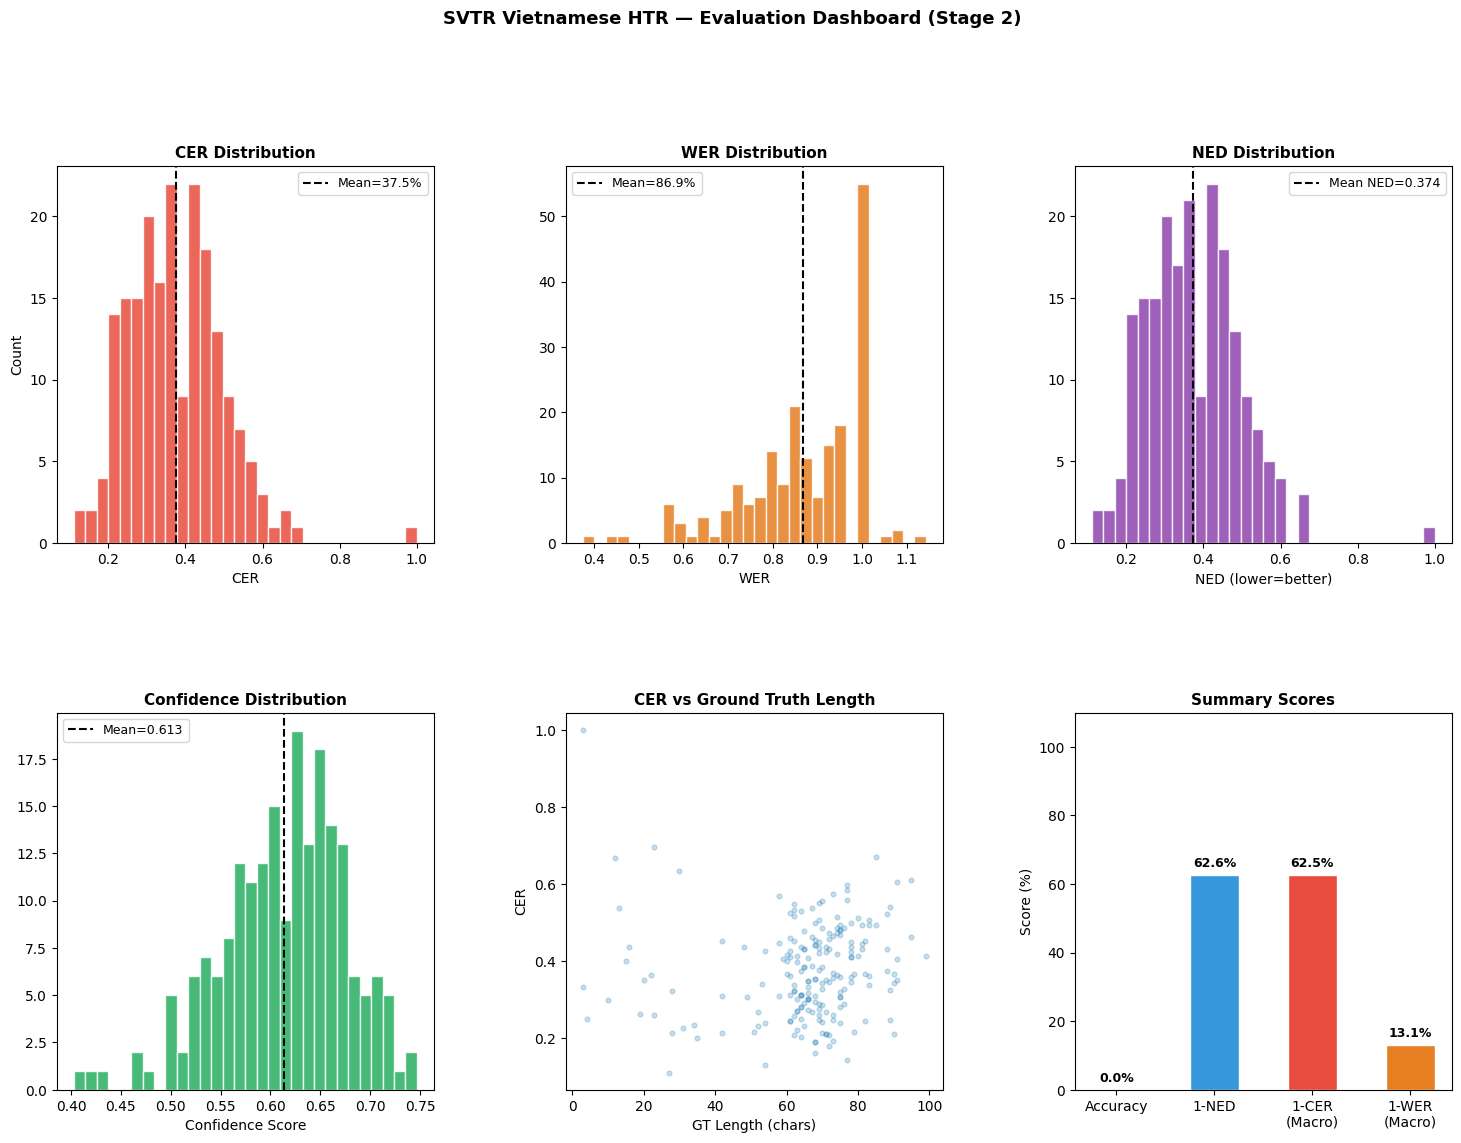

 Chart saved: /kaggle/working/exp_crnn_uit_hwdb/visualizations/eval_dashboard_20260421_113029.png


/tmp/ipykernel_23/897488848.py:253: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(samples_path, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


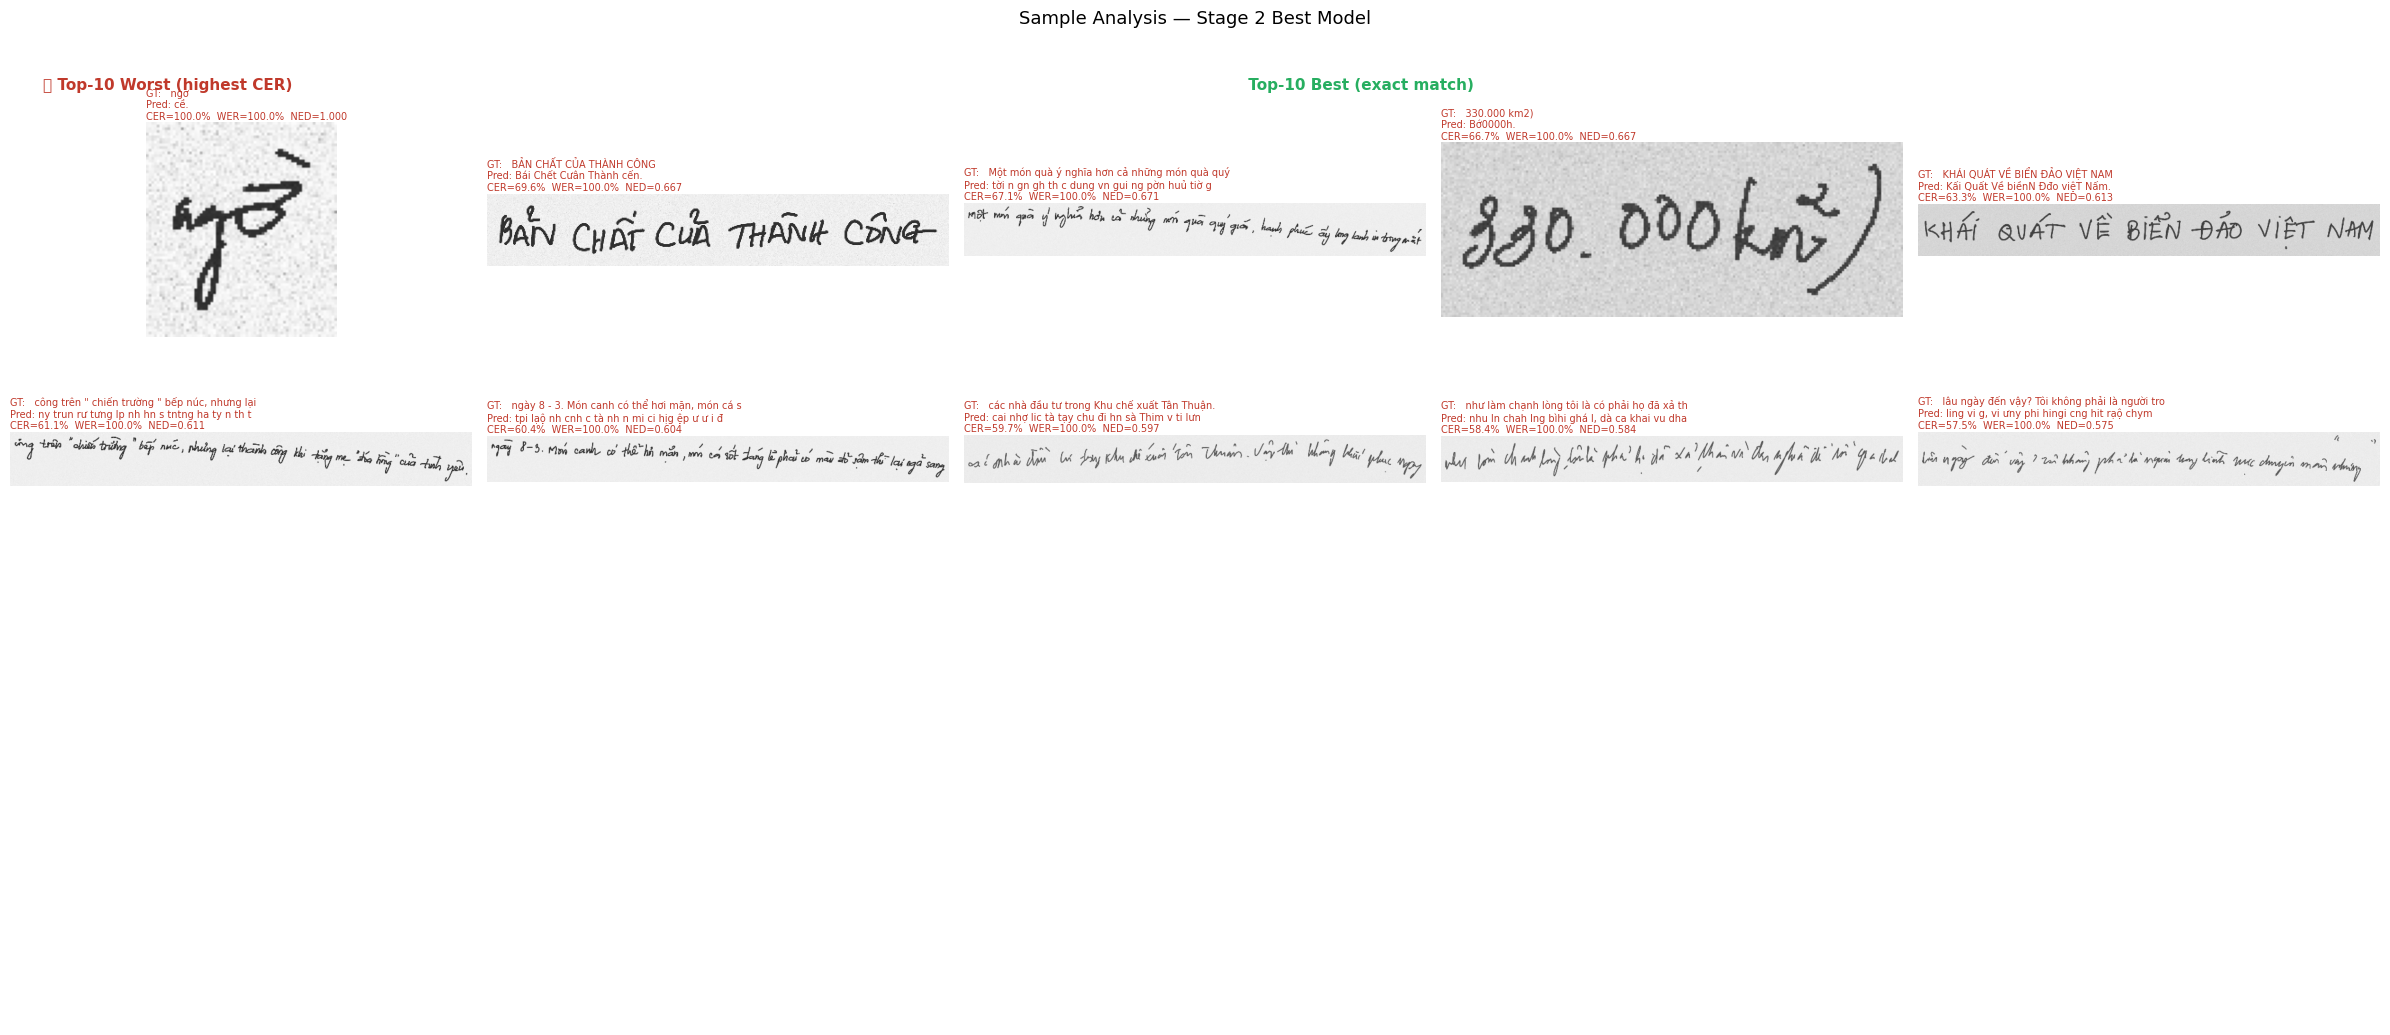

 Sample chart: /kaggle/working/exp_crnn_uit_hwdb/visualizations/sample_analysis_20260421_113029.png


In [16]:
from matplotlib.gridspec import GridSpec
# ------------------------------------------------------------
#  CELL 11 — Đánh giá: CER · WER · NED + CSV Log + Charts
# ------------------------------------------------------------
import csv
import unicodedata

# ── Helper: Levenshtein edit distance ────────────────────────
def levenshtein(a, b):
    """Wagner-Fischer O(mn). Works on list(chars) or list(words)."""
    if a == b:
        return 0
    la, lb = len(a), len(b)
    if la == 0: return lb
    if lb == 0: return la
    prev = list(range(lb + 1))
    for i, ca in enumerate(a, 1):
        curr = [i] + [0] * lb
        for j, cb in enumerate(b, 1):
            curr[j] = min(prev[j] + 1,
                          curr[j-1] + 1,
                          prev[j-1] + (0 if ca == cb else 1))
        prev = curr
    return prev[lb]

def compute_cer(gt: str, pred: str) -> float:
    """Character Error Rate = edit_dist(chars) / len(gt_chars)."""
    gt_c, pred_c = list(gt), list(pred)
    if len(gt_c) == 0:
        return 0.0 if len(pred_c) == 0 else 1.0
    return levenshtein(gt_c, pred_c) / len(gt_c)

def compute_wer(gt: str, pred: str) -> float:
    """Word Error Rate = edit_dist(words) / len(gt_words)."""
    gt_w   = gt.split()
    pred_w = pred.split()
    if len(gt_w) == 0:
        return 0.0 if len(pred_w) == 0 else 1.0
    return levenshtein(gt_w, pred_w) / len(gt_w)

def compute_ned(gt: str, pred: str) -> float:
    """Normalized Edit Distance = edit_dist / max(len(gt), len(pred))."""
    dist = levenshtein(list(gt), list(pred))
    denom = max(len(gt), len(pred))
    return dist / denom if denom > 0 else 0.0

# ── Load Ground Truth ─────────────────────────────────────────
gt = {}
gt_file = f'{DATASET_INPUT}/test_data/labels.txt'
with open(gt_file, 'r', encoding='utf-8') as fh:
    for line in fh:
        line = line.strip()
        if '\t' in line:
            img_path, label = line.split('\t', 1)
            gt[os.path.basename(img_path)] = label

print(f'Ground truth loaded: {len(gt)} samples')
print(f'Predictions loaded : {len(preds)} samples')

# ── Tính metrics từng mẫu ────────────────────────────────────
records = []   # lưu dữ liệu từng dòng để ghi CSV

for img_name, gt_text in gt.items():
    pred_info = preds.get(img_name, {'text': '', 'confidence': None})
    pred_text = pred_info['text'] if pred_info['text'] else ''

    cer   = compute_cer(gt_text, pred_text)
    wer   = compute_wer(gt_text, pred_text)
    ned   = compute_ned(gt_text, pred_text)
    exact = int(pred_text == gt_text)

    records.append({
        'image':      img_name,
        'gt':         gt_text,
        'pred':       pred_text,
        'confidence': pred_info.get('confidence'),
        'exact':      exact,
        'cer':        round(cer, 4),
        'wer':        round(wer, 4),
        'ned':        round(ned, 4),
        'gt_len':     len(gt_text),
        'pred_len':   len(pred_text),
    })

# ── Tổng hợp metrics ─────────────────────────────────────────
total   = len(records)
correct = sum(r['exact'] for r in records)

# Macro averages (per-sample then average)
macro_cer = sum(r['cer'] for r in records) / total if total else 0
macro_wer = sum(r['wer'] for r in records) / total if total else 0
macro_ned = sum(r['ned'] for r in records) / total if total else 0
accuracy  = correct / total if total else 0

# Micro CER/WER (global edit distance over all chars / words)
total_gt_chars = sum(r['gt_len'] for r in records)
total_char_ed  = sum(levenshtein(list(r['gt']), list(r['pred'])) for r in records)
micro_cer      = total_char_ed / total_gt_chars if total_gt_chars else 0

total_gt_words = sum(len(r['gt'].split()) for r in records)
total_word_ed  = sum(levenshtein(r['gt'].split(), r['pred'].split()) for r in records)
micro_wer      = total_word_ed / total_gt_words if total_gt_words else 0

print('\n' + '═'*60)
print('  EVALUATION METRICS')
print('═'*60)
print(f'  Samples          : {total:,}')
print(f'  Exact Match Acc  : {correct}/{total}  = {accuracy*100:.2f}%')
print(f'  Macro CER        : {macro_cer*100:.2f}%')
print(f'  Micro CER        : {micro_cer*100:.2f}%')
print(f'  Macro WER        : {macro_wer*100:.2f}%')
print(f'  Micro WER        : {micro_wer*100:.2f}%')
print(f'  Macro NED        : {macro_ned:.4f}   (lower=better)')
print(f'  1-NED (Accuracy) : {(1-macro_ned)*100:.2f}%')
print('═'*60)

# ── Bảng 20 mẫu đầu ──────────────────────────────────────────
print(f'\n{"STT":>4} | {"?":>3} | {"CER%":>6} | {"WER%":>6} | {"NED":>5} | {"Ground Truth":40s} | {"Prediction":40s}')
print('─' * 120)
for i, r in enumerate(records[:20]):
    mark = '' if r['exact'] else '✗'
    print(f'{i+1:4d} | {mark:>3} | {r["cer"]*100:6.1f} | {r["wer"]*100:6.1f} | {r["ned"]:5.3f} | {r["gt"][:40]:40s} | {r["pred"][:40]:40s}')

# ── Lưu CSV Log ──────────────────────────────────────────────
timestamp_eval = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = f'{LOG_DIR}/eval_results_{timestamp_eval}.csv'
fieldnames = ['image','gt','pred','confidence','exact','cer','wer','ned','gt_len','pred_len']
with open(csv_path, 'w', newline='', encoding='utf-8') as fh:
    writer = csv.DictWriter(fh, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(records)
print(f'\n Per-sample CSV: {csv_path}')

# Lưu summary JSON
summary = {
    'timestamp':   timestamp_eval,
    'total':       total,
    'accuracy':    round(accuracy, 4),
    'macro_cer':   round(macro_cer, 4),
    'micro_cer':   round(micro_cer, 4),
    'macro_wer':   round(macro_wer, 4),
    'micro_wer':   round(micro_wer, 4),
    'macro_ned':   round(macro_ned, 4),
    'one_minus_ned': round(1 - macro_ned, 4),
}
summary_path = f'{LOG_DIR}/eval_summary_{timestamp_eval}.json'
with open(summary_path, 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2)
print(f' Summary JSON  : {summary_path}')

# ── Trực quan hóa metrics ─────────────────────────────────────
cer_vals = [r['cer'] for r in records]
wer_vals = [r['wer'] for r in records]
ned_vals = [r['ned'] for r in records]
conf_vals = [r['confidence'] for r in records if r['confidence'] is not None]

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. CER histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(cer_vals, bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
ax1.axvline(macro_cer, color='black', ls='--', label=f'Mean={macro_cer*100:.1f}%')
ax1.set_title('CER Distribution', fontsize=11, fontweight='bold')
ax1.set_xlabel('CER'); ax1.set_ylabel('Count'); ax1.legend(fontsize=9)

# 2. WER histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(wer_vals, bins=30, color='#e67e22', edgecolor='white', alpha=0.85)
ax2.axvline(macro_wer, color='black', ls='--', label=f'Mean={macro_wer*100:.1f}%')
ax2.set_title('WER Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('WER'); ax2.legend(fontsize=9)

# 3. NED histogram
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(ned_vals, bins=30, color='#8e44ad', edgecolor='white', alpha=0.85)
ax3.axvline(macro_ned, color='black', ls='--', label=f'Mean NED={macro_ned:.3f}')
ax3.set_title('NED Distribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('NED (lower=better)'); ax3.legend(fontsize=9)

# 4. Confidence distribution
ax4 = fig.add_subplot(gs[1, 0])
if conf_vals:
    ax4.hist(conf_vals, bins=30, color='#27ae60', edgecolor='white', alpha=0.85)
    ax4.axvline(sum(conf_vals)/len(conf_vals), color='black', ls='--',
                label=f'Mean={sum(conf_vals)/len(conf_vals):.3f}')
    ax4.legend(fontsize=9)
ax4.set_title('Confidence Distribution', fontsize=11, fontweight='bold')
ax4.set_xlabel('Confidence Score')

# 5. CER vs GT length scatter
ax5 = fig.add_subplot(gs[1, 1])
gt_lens  = [r['gt_len'] for r in records]
ax5.scatter(gt_lens, cer_vals, alpha=0.25, s=12, color='#2980b9')
ax5.set_title('CER vs Ground Truth Length', fontsize=11, fontweight='bold')
ax5.set_xlabel('GT Length (chars)'); ax5.set_ylabel('CER')

# 6. Summary bar chart
ax6 = fig.add_subplot(gs[1, 2])
labels_bar = ['Accuracy', '1-NED', '1-CER\n(Macro)', '1-WER\n(Macro)']
values_bar = [accuracy, 1-macro_ned, 1-macro_cer, 1-macro_wer]
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22']
bars = ax6.bar(labels_bar, [v*100 for v in values_bar], color=colors_bar,
               edgecolor='white', width=0.5)
ax6.set_ylim(0, 110)
ax6.set_ylabel('Score (%)'); ax6.set_title('Summary Scores', fontsize=11, fontweight='bold')
for bar, val in zip(bars, values_bar):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('SVTR Vietnamese HTR — Evaluation Dashboard (Stage 2)',
             fontsize=13, fontweight='bold', y=1.01)
chart_path = f'{VIZ_DIR}/eval_dashboard_{timestamp_eval}.png'
plt.savefig(chart_path, dpi=130, bbox_inches='tight')
plt.show()
print(f' Chart saved: {chart_path}')


# ── Visualization: Top-10 Worst + Top-10 Best Samples ────────
def show_samples(sample_list, title, ax_list, infer_img_dir):
    for ax in ax_list:
        ax.axis('off')
    for i, r in enumerate(sample_list):
        if i >= len(ax_list): break
        img_path = os.path.join(infer_img_dir, r['image'])
        img_rgb  = load_img_rgb(img_path, max_h=80)
        color    = '#c0392b' if r['exact'] == 0 else '#27ae60'
        ax_list[i].imshow(img_rgb)
        ax_list[i].set_title(
            f"GT:   {r['gt'][:45]}\nPred: {r['pred'][:45]}\n"
            f"CER={r['cer']*100:.1f}%  WER={r['wer']*100:.1f}%  NED={r['ned']:.3f}",
            fontsize=7, color=color, loc='left', pad=2
        )
        ax_list[i].axis('off')

sorted_by_cer = sorted(records, key=lambda x: x['cer'], reverse=True)
best_exact    = [r for r in records if r['exact'] == 1][:10]
worst_10      = sorted_by_cer[:10]

fig2, axes2 = plt.subplots(4, 5, figsize=(24, 10))
axes2_flat = axes2.flatten()
show_samples(worst_10,   'Worst',  axes2_flat[:10],  INFER_IMG_DIR)
show_samples(best_exact, 'Best',   axes2_flat[10:20], INFER_IMG_DIR)

# Section labels
fig2.text(0.02, 0.95, '❌ Top-10 Worst (highest CER)',
          fontsize=11, fontweight='bold', color='#c0392b')
fig2.text(0.52, 0.95, ' Top-10 Best (exact match)',
          fontsize=11, fontweight='bold', color='#27ae60')
plt.suptitle('Sample Analysis — Stage 2 Best Model', fontsize=13, y=1.03)
plt.tight_layout()
samples_path = f'{VIZ_DIR}/sample_analysis_{timestamp_eval}.png'
plt.savefig(samples_path, dpi=120, bbox_inches='tight')
plt.show()
print(f' Sample chart: {samples_path}')

### Bước 10 - Quick Run Order
Cell này chỉ in thứ tự thực thi gợi ý để tránh sót bước khi chạy trên Kaggle.

In [17]:
# ------------------------=
# 10) Quick run order (manual)
# ------------------------=
print('Suggested execution order:')
print('0.1) Install base dependencies (Paddle)')
print('0.2) Clone PaddleOCR + requirements')
print('0.3) (Optional) Login HuggingFace via Kaggle Secrets')
print('1) Environment setup + dataset paths')
print('2) Validate dataset & convert labels')
print('3) Build Vietnamese dictionary')
print('4) Visualize text length → choose max_text_length')
print('5) Download pretrained CRNN (Chinese)')
print('6) Build YAML config (update MAX_TEXT_LENGTH first!)')
print('6.5) Patch HandwritingAug + freeze/early stop patch')
print('7) Run Stage 1: freeze backbone/necks + warmup head')
print('8) Run Stage 2: full fine-tuning')
print('9) Run inference on test set')
print('10) Compute CER + NED')


Suggested execution order:
0.1) Install base dependencies (Paddle)
0.2) Clone PaddleOCR + requirements
0.3) (Optional) Login HuggingFace via Kaggle Secrets
1) Environment setup + dataset paths
2) Validate dataset & convert labels
3) Build Vietnamese dictionary
4) Visualize text length → choose max_text_length
5) Download pretrained CRNN (Chinese)
6) Build YAML config (update MAX_TEXT_LENGTH first!)
6.5) Patch HandwritingAug + freeze/early stop patch
7) Run Stage 1: freeze backbone/necks + warmup head
8) Run Stage 2: full fine-tuning
9) Run inference on test set
10) Compute CER + NED
